In [1]:
%matplotlib widget

# Machine learning

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors
import random
import itertools

from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Load models and data

models = np.load('Models/models_UC.npy')
data = np.load('Data/data_UC.npy')

Data = pd.DataFrame(np.hstack((models, data)), columns = ['h1', 'logs1', 'logs2', 'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                                      'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'])

In [4]:
Data

,h1,logs1,logs2,h2op,h4op,h8op,h2ip,h4ip,h8ip,v2op,...,v8op,v2ip,v4ip,v8ip,p2op,p4op,p8op,p2ip,p4ip,p8ip
0,0.1,-3.000000,-3.000000,-0.068852,-0.272346,-1.048557,-0.001328,-0.010475,-0.081356,-0.095568,...,-1.142350,-0.001804,-0.014114,-0.109296,0.060456,0.262661,1.092273,0.000025,0.000346,0.004641
1,0.1,-2.938776,-3.000000,-0.068747,-0.272240,-1.048457,-0.001328,-0.010470,-0.081325,-0.097590,...,-1.153980,-0.001807,-0.014124,-0.109330,0.059397,0.260518,1.087974,0.000025,0.000346,0.004641
2,0.1,-2.938776,-2.938776,-0.079173,-0.312711,-1.200211,-0.001639,-0.012911,-0.100050,-0.109905,...,-1.305806,-0.002223,-0.017390,-0.134407,0.069617,0.302455,1.257627,0.000033,0.000451,0.006031
3,0.1,-2.877551,-3.000000,-0.068625,-0.272118,-1.048342,-0.001327,-0.010465,-0.081290,-0.099780,...,-1.167211,-0.001810,-0.014134,-0.109369,0.058178,0.258050,1.083024,0.000025,0.000345,0.004640
4,0.1,-2.877551,-2.938776,-0.079051,-0.312589,-1.200097,-0.001638,-0.012905,-0.100010,-0.112233,...,-1.319200,-0.002226,-0.017400,-0.134446,0.068398,0.299988,1.252677,0.000033,0.000451,0.006031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63745,6.0,0.000000,-0.244898,-30.552589,-5.858484,342.328001,-24.112416,-103.320801,-76.358040,-42.780358,...,772.431546,-35.288381,-148.742092,-80.219229,56.827498,211.051236,502.748663,7.555902,70.180024,445.693938
63746,6.0,0.000000,-0.183673,-30.611660,-6.298405,340.049094,-24.069703,-103.093507,-76.680055,-42.808919,...,770.870305,-35.260518,-148.553873,-79.487709,56.818472,210.904753,500.647768,7.572182,70.396517,447.287672
63747,6.0,0.000000,-0.122449,-30.676302,-6.776174,337.660568,-24.025072,-102.861800,-77.126549,-42.840357,...,769.187071,-35.231295,-148.357963,-78.758189,56.808174,210.738936,498.326195,7.589726,70.628079,448.925926
63748,6.0,0.000000,-0.061224,-30.746731,-7.292466,335.177609,-23.978762,-102.627930,-77.710018,-42.874803,...,767.382533,-35.200838,-148.155451,-78.039328,56.796476,210.552126,495.776267,7.608527,70.874218,450.591946


In [5]:
Data = Data.sample(10000, random_state=42)

# Analize available data

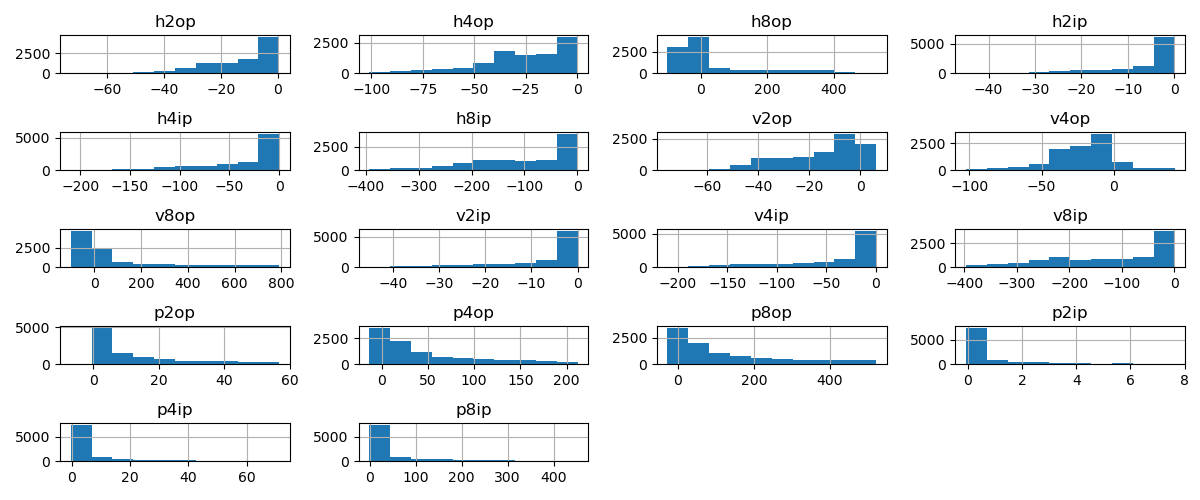

In [6]:
# Scale data and models

ydata = Data[['h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
               'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip']]
ydata.hist(figsize=(12,5))
plt.tight_layout()
plt.show()

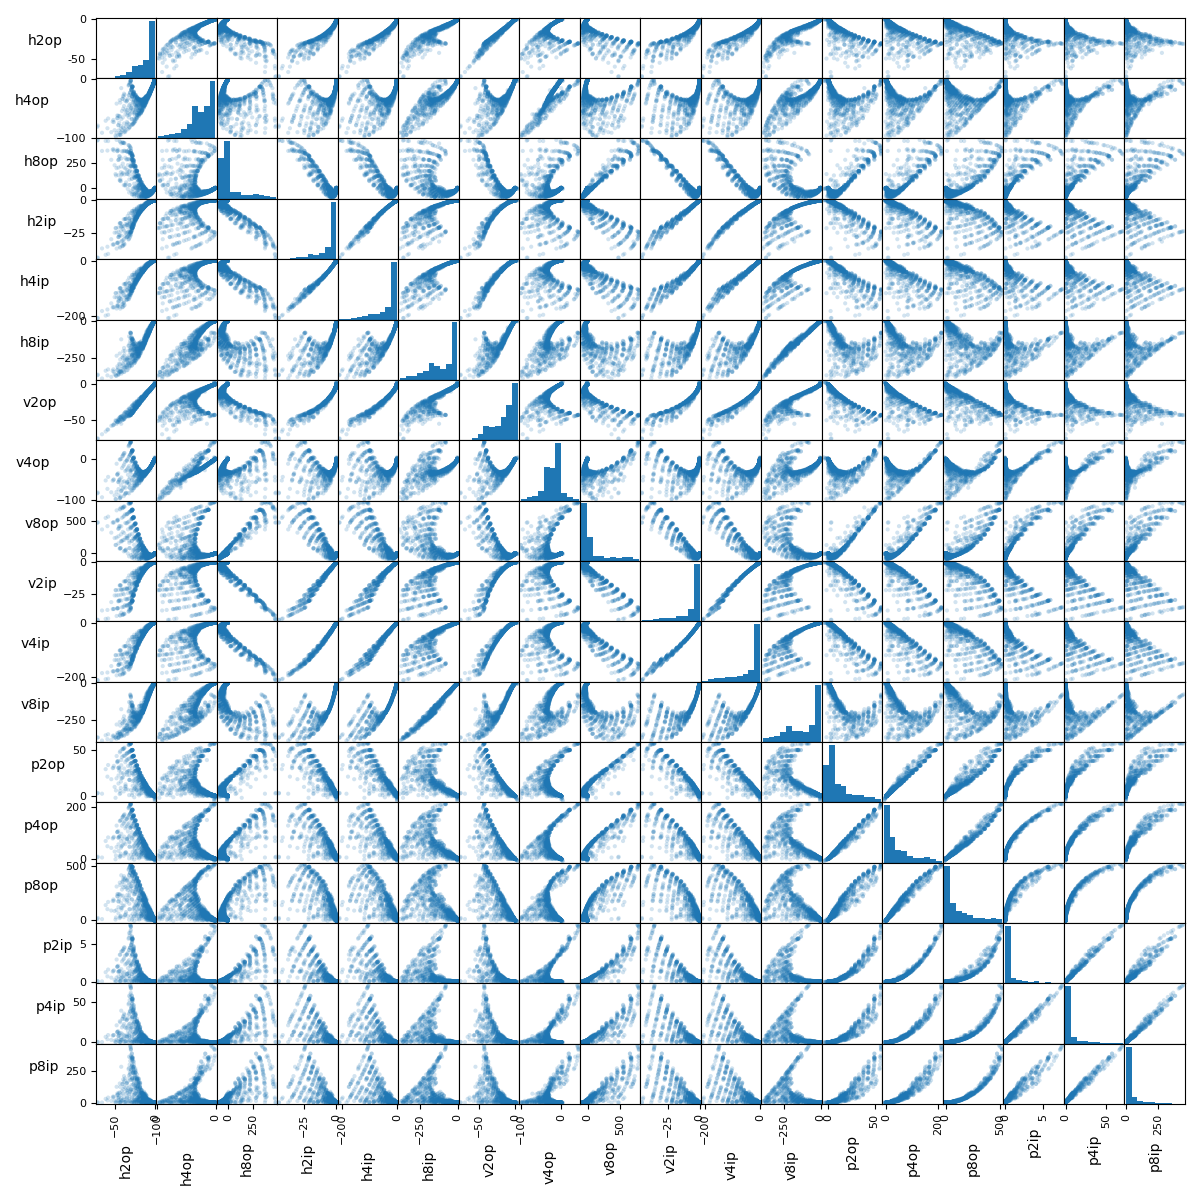

In [7]:
 # Check possible correlations
datasamp = ydata.sample(1000)

axes = pd.plotting.scatter_matrix(datasamp, alpha=0.2, figsize =(12,12))
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

Text(0.5, 1.0, 'Correlation to h1')

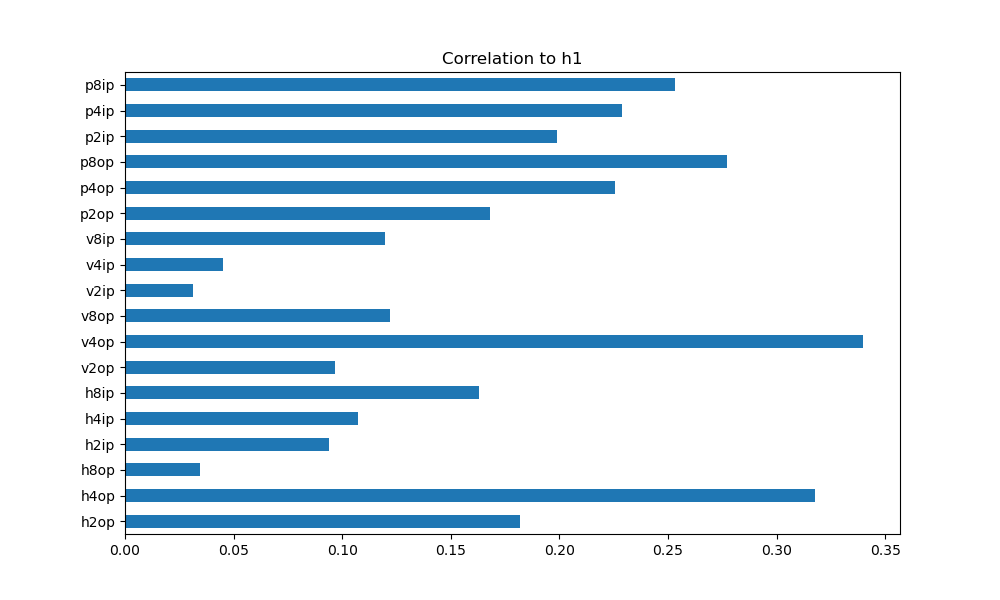

In [8]:
plt.figure()
correlation_values_h1 = Data.corr()['h1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to h1')

Text(0.5, 1.0, 'Correlation to s1')

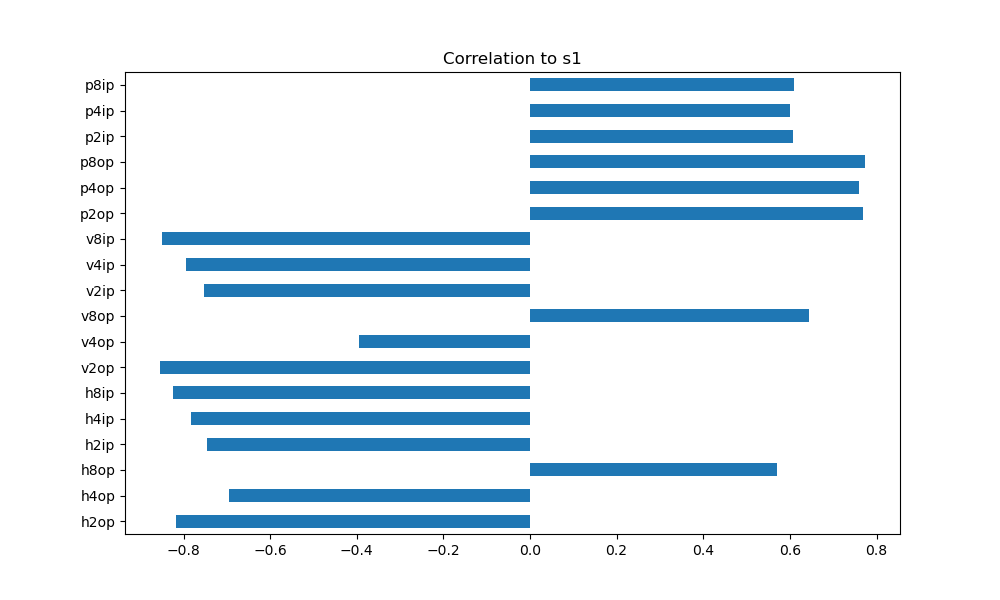

In [9]:
plt.figure()
correlation_values_h1 = Data.corr()['logs1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s1')

Text(0.5, 1.0, 'Correlation to s2')

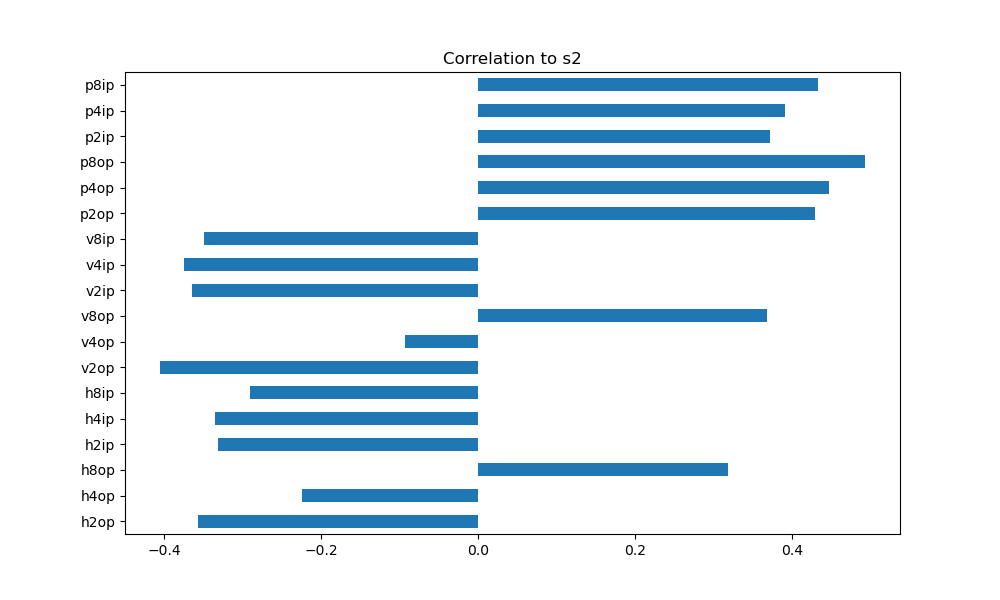

In [10]:
plt.figure()
correlation_values_h1 = Data.corr()['logs2'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s2')

<Axes: >

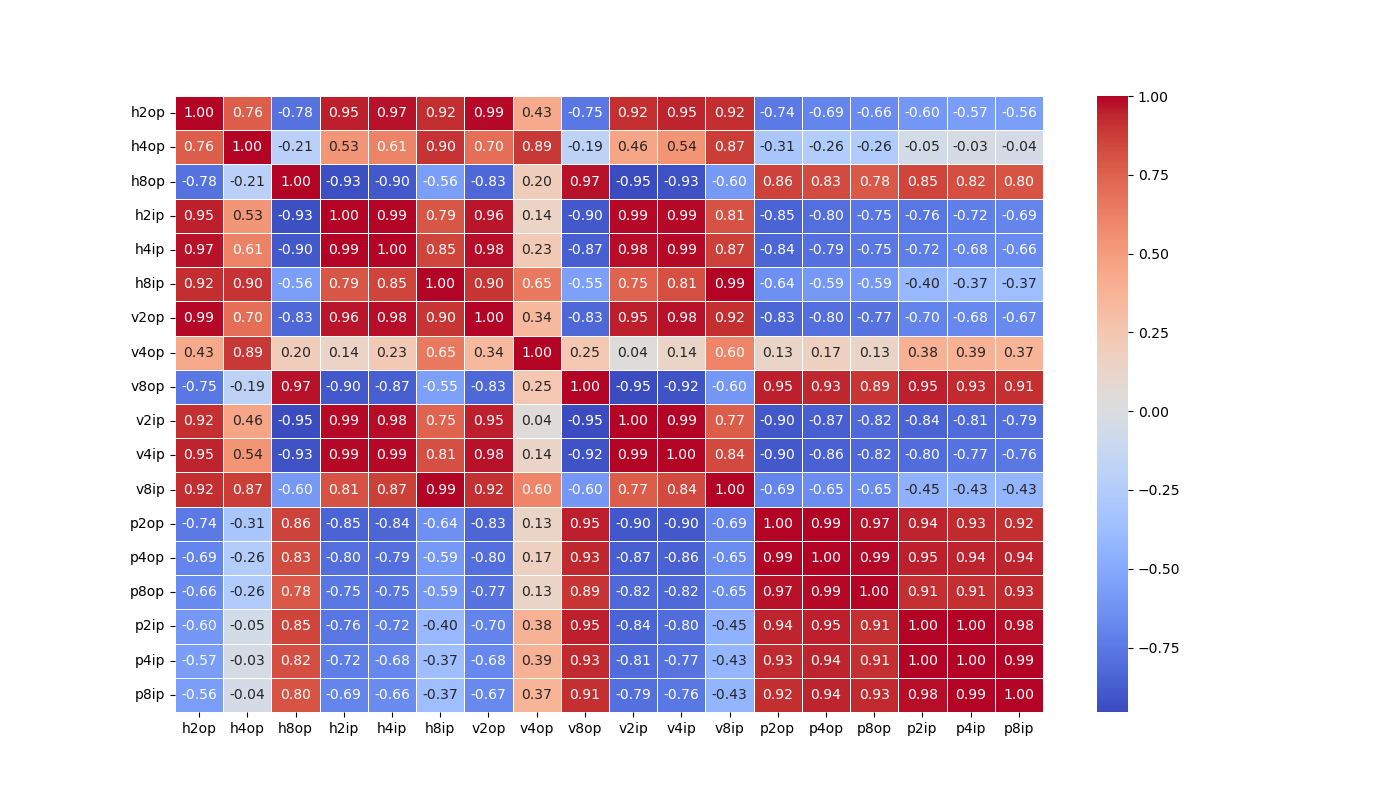

In [11]:

plt.figure(figsize=(14, 8))
correlation_matrix = ydata.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Standarize dataset

In [12]:
scale_x = StandardScaler()
scale_y = StandardScaler()

Data_X = Data.drop(['h1', 'logs1', 'logs2'], axis=1)
Data_y = Data.drop(['h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                    'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'], axis=1)

X = scale_x.fit_transform(Data_X)
y = scale_y.fit_transform(Data_y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

## Add noise to y_train

In [14]:
noise_std = 0.05
rng = np.random.RandomState(1)
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)
X_train_noisy = X_train + rng.normal(loc=0.0, scale=noise_std, size=X_train.shape)

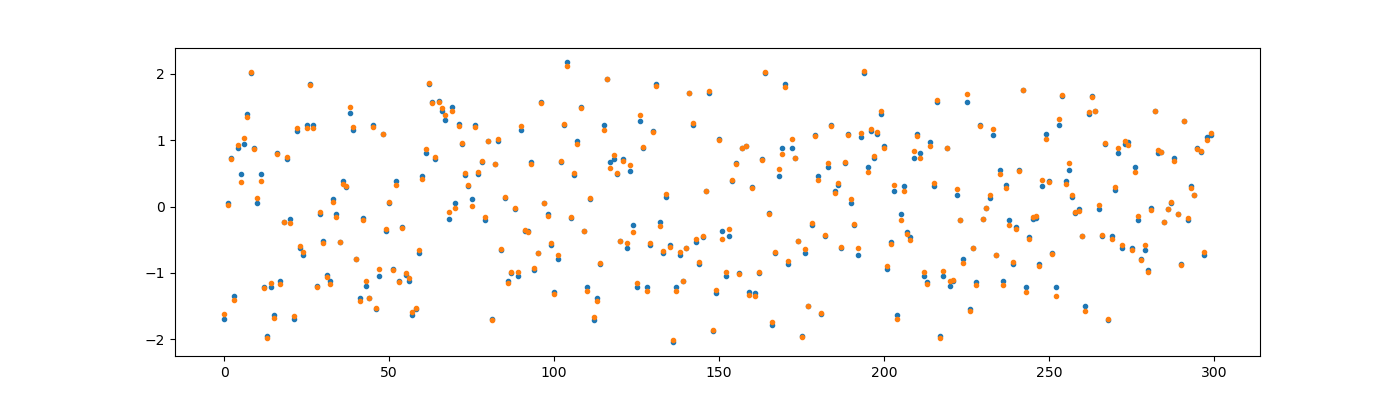

In [15]:
plt.figure(figsize = (14,4))
plt.plot(y_train[:100].ravel(), '.')
plt.plot(y_train_noisy[:100].ravel(), '.')

# Grid search of MLP Regressor

In [16]:
# Define the model
mlp = MLPRegressor(max_iter=2000, early_stopping=True, random_state=42)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (50, 50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
}

# Set up the grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=20, verbose=1)

# Fit the model
grid_search.fit(X_train_noisy, y_train_noisy)

# Best parameters
# Best parameters
print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best R² score: 0.7650689773055339


In [17]:
# Enter your code here
test_score = grid_search.score(X_test, y_test)
print(f"{test_score:.3f}")

0.804


In [18]:
# Make predictions on the entire test set
y_pred = grid_search.predict(X_test)

# Compute metrics for each output variable separately
for i in range(y_test.shape[1]):  # Loop through each target variable
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    
    print(f"Output variable {i+1}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}\n")

Output variable 1:
  R² Score: 0.6774
  Mean Absolute Error (MAE): 0.3583
  Mean Squared Error (MSE): 0.3280

Output variable 2:
  R² Score: 0.9712
  Mean Absolute Error (MAE): 0.0650
  Mean Squared Error (MSE): 0.0293

Output variable 3:
  R² Score: 0.7634
  Mean Absolute Error (MAE): 0.3963
  Mean Squared Error (MSE): 0.2369



In [19]:
n = 50

# Define a single test sample (ensure it's 2D: shape (1, n_features))
X_test_single = X_test[n].reshape(1, -1)  # Pick the first test sample

# Make prediction
y_pred_single = grid_search.predict(X_test_single)

# Print the predicted value
print("Predicted output for the single test sample:", scale_y.inverse_transform(y_pred_single))
print('True output for the test sample             ', scale_y.inverse_transform(y_test[n].reshape(1, -1)))
mse = mean_squared_error(y_test[n], y_pred_single[0])
print('mean squared error:', mse)

Predicted output for the single test sample: [[ 4.60870667 -0.88493642 -1.08495493]]
True output for the test sample              [[ 5.87959184 -0.85714286 -1.04081633]]
mean squared error: 0.1820015372845013


Text(0.5, 1.0, 'log s2 - r2: 0.7634')

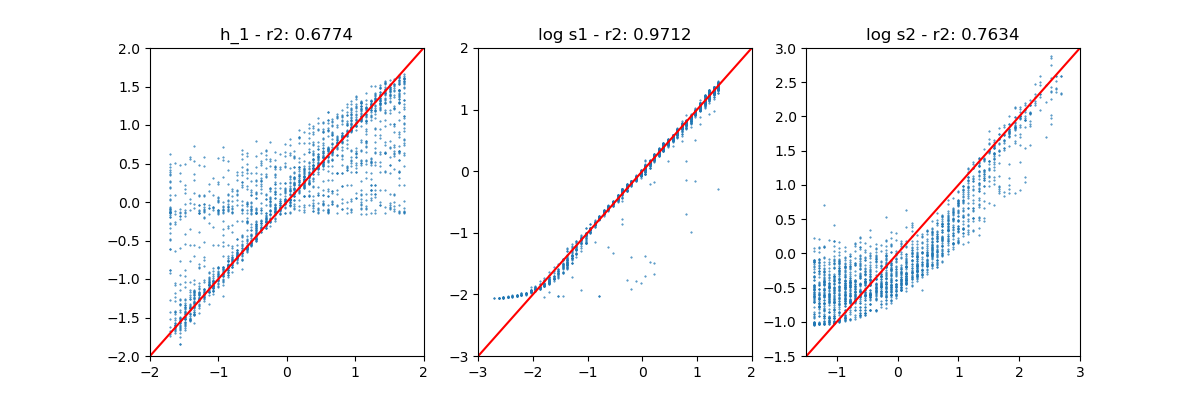

In [20]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].scatter(y_test[:,0], y_pred[:,0], s=0.2)
r2_h1 = r2_score(y_test[:, 0], y_pred[:, 0])
ax[0].plot([-2, 2], [-2, 2], 'r')
ax[1].scatter(y_test[:,1], y_pred[:,1], s=0.2)
r2_s1 = r2_score(y_test[:, 1], y_pred[:, 1])
ax[1].plot([-3,2], [-3,2], 'r')
ax[2].scatter(y_test[:,2], y_pred[:,2], s=0.2)
r2_s2 = r2_score(y_test[:, 2], y_pred[:, 2])
ax[2].plot([-1.5, 3], [-1.5, 3], 'r')

ax[0].set_xlim([-2, 2])
ax[0].set_ylim([-2, 2])

ax[1].set_xlim([-3, 2])
ax[1].set_ylim([-3, 2])

ax[2].set_xlim([-1.5, 3])
ax[2].set_ylim([-1.5, 3])

ax[0].set_title(f'h_1 - r2: {r2_h1:.4f}')
ax[1].set_title(f'log s1 - r2: {r2_s1:.4f}')
ax[2].set_title(f'log s2 - r2: {r2_s2:.4f}')

# Reduce variables in X

In [21]:
models = np.load('Models/models_UC.npy')
data = np.load('Data/data_UC.npy')

Data = pd.DataFrame(np.hstack((models, data)), columns = ['h1', 'logs1', 'logs2', 'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                                      'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'])

Data = Data.drop(['h2ip', 'h4ip', 'v2op', 'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op','p4op','p2ip','p4ip'], axis=1)

Data

,h1,logs1,logs2,h2op,h4op,h8op,h8ip,v4op,p8op,p8ip
0,0.1,-3.000000,-3.000000,-0.068852,-0.272346,-1.048557,-0.081356,-0.327748,1.092273,0.004641
1,0.1,-2.938776,-3.000000,-0.068747,-0.272240,-1.048457,-0.081325,-0.332953,1.087974,0.004641
2,0.1,-2.938776,-2.938776,-0.079173,-0.312711,-1.200211,-0.100050,-0.376215,1.257627,0.006031
3,0.1,-2.877551,-3.000000,-0.068625,-0.272118,-1.048342,-0.081290,-0.338791,1.083024,0.004640
4,0.1,-2.877551,-2.938776,-0.079051,-0.312589,-1.200097,-0.100010,-0.382210,1.252677,0.006031
...,...,...,...,...,...,...,...,...,...,...
63745,6.0,0.000000,-0.244898,-30.552589,-5.858484,342.328001,-76.358040,39.893197,502.748663,445.693938
63746,6.0,0.000000,-0.183673,-30.611660,-6.298405,340.049094,-76.680055,39.668682,500.647768,447.287672
63747,6.0,0.000000,-0.122449,-30.676302,-6.776174,337.660568,-77.126549,39.422716,498.326195,448.925926
63748,6.0,0.000000,-0.061224,-30.746731,-7.292466,335.177609,-77.710018,39.154547,495.776267,450.591946


In [22]:
Data = Data.sample(10000, random_state=42)

Text(0.5, 1.0, 'Correlation to h1')

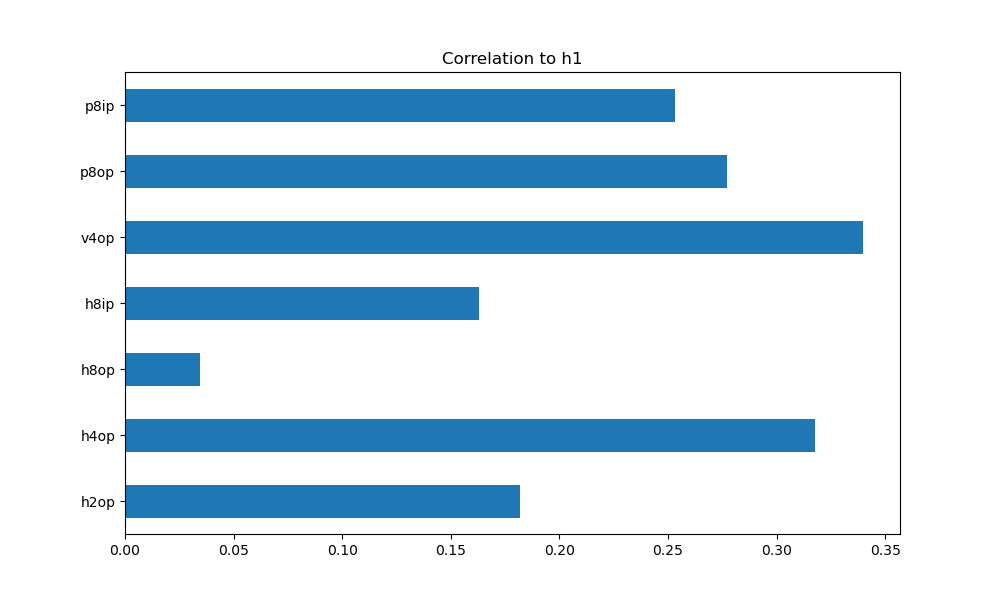

In [23]:
plt.figure()
correlation_values_h1 = Data.corr()['h1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to h1')

Text(0.5, 1.0, 'Correlation to s1')

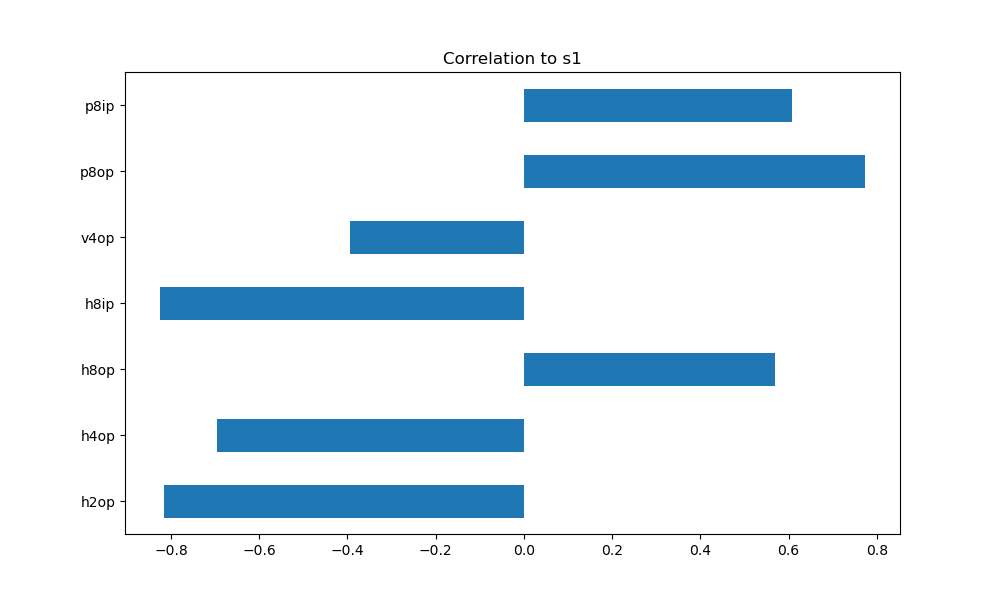

In [24]:
plt.figure()
correlation_values_h1 = Data.corr()['logs1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s1')

Text(0.5, 1.0, 'Correlation to s2')

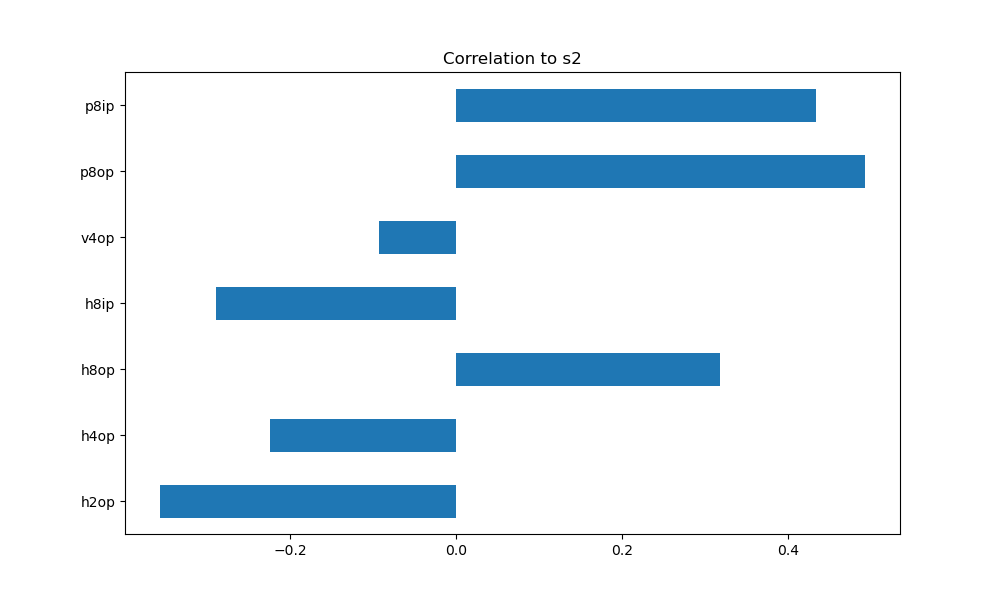

In [25]:
plt.figure()
correlation_values_h1 = Data.corr()['logs2'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s2')

<Axes: >

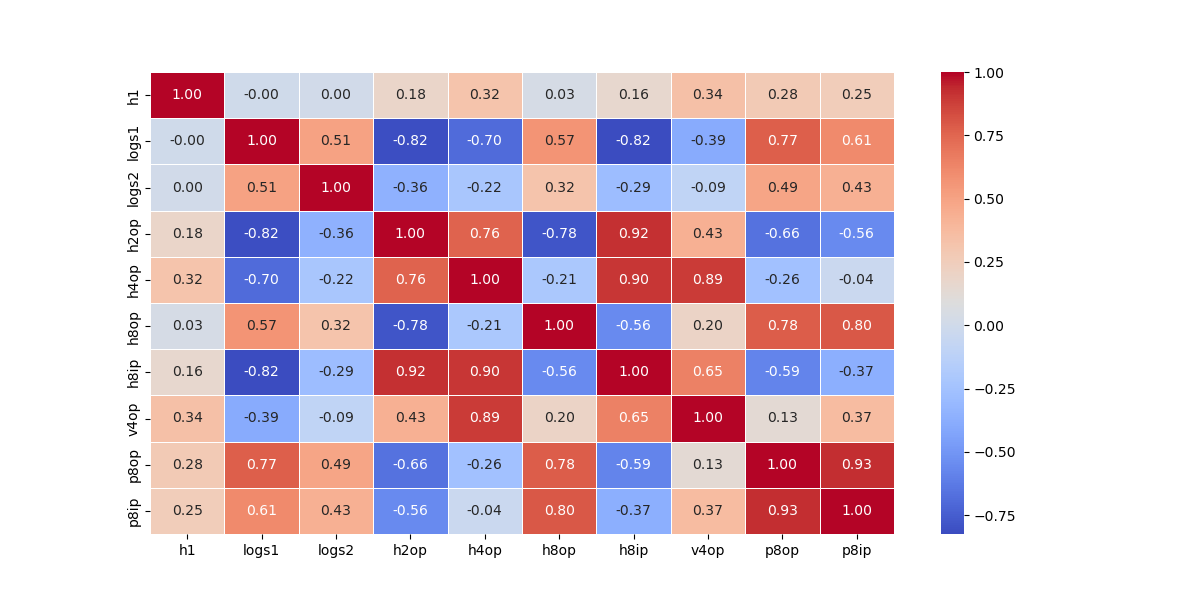

In [26]:
plt.figure(figsize=(12, 6))
correlation_matrix = Data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [27]:
# Standarize

scale_x = StandardScaler()
scale_y = StandardScaler()

Data_X = Data.drop(['h1', 'logs1', 'logs2'], axis=1)
Data_y = Data.drop(['h2op', 'h4op', 'h8op', 'h8ip', 'v4op',
                     'p8op', 'p8ip'], axis=1)

X = scale_x.fit_transform(Data_X)
y = scale_y.fit_transform(Data_y)
# Split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Add noise

noise_std = 0.05
rng = np.random.RandomState(1)
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)
X_train_noisy = X_train + rng.normal(loc=0.0, scale=noise_std, size=X_train.shape)

In [28]:
# Define the model
mlp = MLPRegressor(max_iter=2000, early_stopping=True, random_state=42)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (50, 50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
}

# Set up the grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=20, verbose=1)

# Fit the model
grid_search.fit(X_train_noisy, y_train_noisy)

# Best parameters
# Best parameters
print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best R² score: 0.7511189249480559


In [29]:
test_score = grid_search.score(X_test, y_test)
print(f"{test_score:.3f}")

0.792


In [30]:
# Make predictions on the entire test set
y_pred = grid_search.predict(X_test)

# Compute metrics for each output variable separately
for i in range(y_test.shape[1]):  # Loop through each target variable
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    
    print(f"Output variable {i+1}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}\n")

Output variable 1:
  R² Score: 0.6718
  Mean Absolute Error (MAE): 0.3650
  Mean Squared Error (MSE): 0.3337

Output variable 2:
  R² Score: 0.9500
  Mean Absolute Error (MAE): 0.0835
  Mean Squared Error (MSE): 0.0508

Output variable 3:
  R² Score: 0.7548
  Mean Absolute Error (MAE): 0.4049
  Mean Squared Error (MSE): 0.2455



In [31]:
n = 200

# Define a single test sample (ensure it's 2D: shape (1, n_features))
X_test_single = X_test[n].reshape(1, -1)  # Pick the first test sample

# Make prediction
y_pred_single = grid_search.predict(X_test_single)

# Print the predicted value
print("Predicted output for the single test sample:", scale_y.inverse_transform(y_pred_single))
print('True output for the test sample             ', scale_y.inverse_transform(y_test[n].reshape(1, -1)))
mse = mean_squared_error(y_test[n], y_pred_single[0])
print('mean squared error:', mse)

Predicted output for the single test sample: [[ 4.27942856 -0.44223166 -2.11667709]]
True output for the test sample              [[ 4.43469388 -0.42857143 -2.69387755]]
mean squared error: 0.2155804845412255


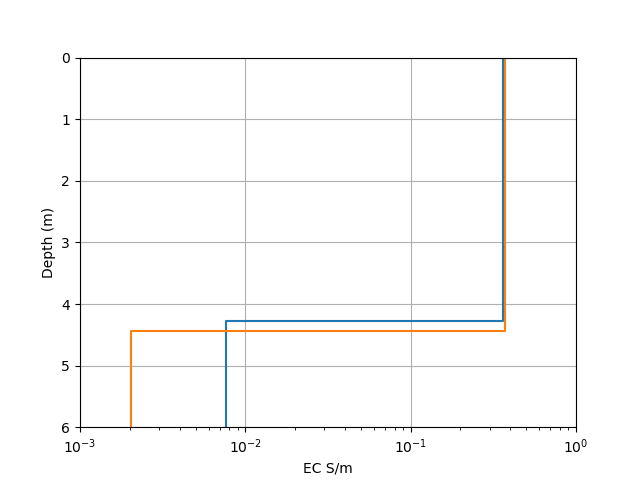

In [32]:
fig, ax = plt.subplots()

y_true_scaled = scale_y.inverse_transform(y_test[n].reshape(1, -1))
s_true = 10**y_true_scaled[0][1:]
h1_true = [y_true_scaled[0]]

y_pred_scaled = scale_y.inverse_transform(y_pred_single)
s_pred = 10**y_pred_scaled[0][1:]
h1_pred = [y_pred_scaled[0]]

drawModel1D(values=s_pred, thickness=h1_pred, ax=ax, label ='Pred' , zmax=7, xlabel='EC S/m')
drawModel1D(values=s_true, thickness=h1_true, ax=ax, label ='True' , zmax=7, xlabel='EC S/m')
ax.set_ylim([6, 0])
ax.set_xlim([1/1000, 1])
ax.set_xscale('log')

Text(0.5, 1.0, 'log s2 - r2: 0.7548')

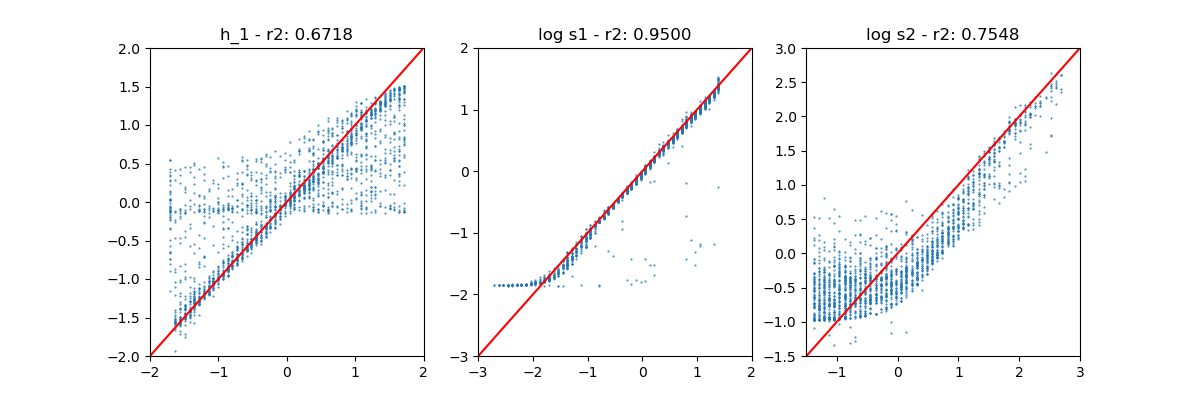

In [33]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].scatter(y_test[:,0], y_pred[:,0], s=0.2)
r2_h1 = r2_score(y_test[:, 0], y_pred[:, 0])
ax[0].plot([-2, 2], [-2, 2], 'r')
ax[1].scatter(y_test[:,1], y_pred[:,1], s=0.2)
r2_s1 = r2_score(y_test[:, 1], y_pred[:, 1])
ax[1].plot([-3,2], [-3,2], 'r')
ax[2].scatter(y_test[:,2], y_pred[:,2], s=0.2)
r2_s2 = r2_score(y_test[:, 2], y_pred[:, 2])
ax[2].plot([-1.5, 3], [-1.5, 3], 'r')

ax[0].set_xlim([-2, 2])
ax[0].set_ylim([-2, 2])

ax[1].set_xlim([-3, 2])
ax[1].set_ylim([-3, 2])

ax[2].set_xlim([-1.5, 3])
ax[2].set_ylim([-1.5, 3])

ax[0].set_title(f'h_1 - r2: {r2_h1:.4f}')
ax[1].set_title(f'log s1 - r2: {r2_s1:.4f}')
ax[2].set_title(f'log s2 - r2: {r2_s2:.4f}')

In [ ]:
grid_search.